<a href="https://colab.research.google.com/github/avocado-planet/01-ReAct-Agent-Sample/blob/main/langgraph_openai_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# LangGraphを使ったエージェント実装 (OpenAI API版)

このノートブックでは、LangGraphとOpenAI APIを使ってシンプルなエージェントを構築します。

## 📝 事前準備

1. 左サイドバーの🔑アイコンをクリック
2. Secretsに `OPENAI_API_KEY` を追加
3. Notebook accessをONにする

## 1️⃣ パッケージのインストール

In [1]:
!pip install langgraph langchain-openai langchain-core -q
print("✅ パッケージのインストール完了")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.6/98.6 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 515.1/515.1 kB 19.5 MB/s eta 0:00:00
✅ パッケージのインストール完了


## 2️⃣ 必要なライブラリのインポート

In [2]:
from typing import TypedDict, Annotated, Literal
from langgraph.graph import StateGraph, END
from langgraph.prebuilt import ToolNode
from langchain_core.messages import HumanMessage, AIMessage, ToolMessage
from langchain_core.tools import tool
from langchain_openai import ChatOpenAI
import operator

print("✅ インポート完了")

✅ インポート完了


## 3️⃣ API Keyの取得

In [3]:
# Google Colab の Secrets から API Key を取得
from google.colab import userdata

try:
    OPENAI_API_KEY = userdata.get('OPENAI_API_KEY')
    print("API Keyを取得しました")
except Exception as e:
    print(f"エラー: {e}")
    print("左サイドバーの🔑から OPENAI_API_KEY を設定してください")

API Keyを取得しました


## 4️⃣ ツールの定義

エージェントが使用できる3つのツールを定義します。

In [7]:
@tool
def get_weather(city: str) -> str:
    #LLMは以下docstringのもとにツールの使用を判断します。
    #LangChainの@toolを使う場合はdocstringの記述は下記のようにGoogle Styleで書く必要があります。
    #Args:セクションのパラメータ名と説明をパースしてLLMに渡すスキーマを生成するため、別のスタイルだと正しく解析されない可能性があります
    """指定された都市の天気を取得します。

    Args:
        city: 天気を知りたい都市名
    """
    weather_data = {
        "東京": "晴れ、気温25度",
        "大阪": "曇り、気温23度",
        "札幌": "雨、気温18度",
        "福岡": "晴れ、気温27度",
    }
    return weather_data.get(city, f"{city}の天気情報は見つかりませんでした")


@tool
def calculate(expression: str) -> str:
    """数式を計算します。

    Args:
        expression: 計算したい数式（例: "2 + 3 * 4"）
    """
    try:
        result = eval(expression)
        return f"{expression} = {result}"
    except Exception as e:
        return f"計算エラー: {str(e)}"


@tool
def get_current_time() -> str:
    """現在の日時を取得します。"""
    from datetime import datetime
    now = datetime.now()
    return now.strftime("%Y年%m月%d日 %H:%M:%S")


# ツールのリスト
tools = [get_weather, calculate, get_current_time]
print(f"{len(tools)}個のツールを定義しました")

3個のツールを定義しました


## 5️⃣ エージェントの状態定義

In [6]:
class AgentState(TypedDict):
    """エージェントの状態を管理

    messages: 会話履歴
        - operator.add により、新しいメッセージが既存リストに追加される
    """
    messages: Annotated[list, operator.add]

print("状態クラスを定義しました")

状態クラスを定義しました


## 6️⃣ LLMの初期化

In [8]:
# OpenAI GPTモデルの初期化
llm = ChatOpenAI(
    model="gpt-4o-mini",  # コスト効率の良いモデル
    temperature=0,  # 決定論的な応答
    api_key=OPENAI_API_KEY
)

# ツールをLLMにバインド
llm_with_tools = llm.bind_tools(tools)

print("LLMを初期化しました")

LLMを初期化しました


## 7️⃣ ノード関数の定義

In [9]:
def call_model(state: AgentState) -> dict:
    """LLMを呼び出すノード

    会話履歴をLLMに渡し、次のアクションを決定します。
    """
    messages = state["messages"]
    response = llm_with_tools.invoke(messages)
    return {"messages": [response]}


def should_continue(state: AgentState) -> Literal["tools", "end"]:
    """次のステップを決定

    ツール呼び出しが必要 → "tools"
    最終回答 → "end"
    """
    messages = state["messages"]
    last_message = messages[-1]

    if hasattr(last_message, "tool_calls") and last_message.tool_calls:
        return "tools"
    return "end"

print("ノード関数を定義しました")

ノード関数を定義しました


## 8️⃣ グラフの構築

In [10]:
# グラフの初期化
workflow = StateGraph(AgentState)

# ノードの追加
workflow.add_node("agent", call_model)
workflow.add_node("tools", ToolNode(tools))

# エントリーポイント
workflow.set_entry_point("agent")

# 条件付きエッジ: agentノードから分岐
workflow.add_conditional_edges(
    "agent",
    should_continue,
    {
        "tools": "tools",
        "end": END
    }
)

# toolsノードは常にagentに戻る
workflow.add_edge("tools", "agent")

# コンパイル
app = workflow.compile()

print("グラフを構築しました")

グラフを構築しました


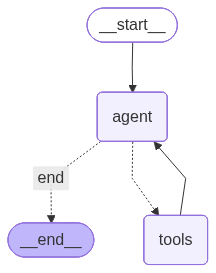

In [14]:
#便利なグラフ構造を出力する方法
app

## 9️⃣ 実行用のヘルパー関数

In [16]:
def run_agent(user_input: str, verbose: bool = True):
    """エージェントを実行"""

    # ── ヘッダー表示 ──
    print(f"\n{'='*70}")
    print(f"👤 ユーザー: {user_input}")
    print(f"{'='*70}\n")

    # ユーザー入力をHumanMessageとして初期状態にセット
    initial_state = {
        "messages": [HumanMessage(content=user_input)]
    }

    # グラフをストリーミング実行し、ステップごとに出力を処理
    for step, output in enumerate(app.stream(initial_state), 1):
        if verbose:
            print(f"📍 --- ステップ {step} ---")

        # 各ステップは {ノード名: 出力} の辞書
        for node_name, node_output in output.items():
            if verbose:
                print(f"   ノード: {node_name}")

            if "messages" in node_output:
                for msg in node_output["messages"]:

                    # ── AI（LLM）からの応答 ──
                    if isinstance(msg, AIMessage):
                        if msg.content:
                            print(f"\n🤖 AI応答: {msg.content}\n")

                        # LLMがツール呼び出しを決定した場合
                        if hasattr(msg, "tool_calls") and msg.tool_calls:
                            for tool_call in msg.tool_calls:
                                if verbose:
                                    print(f"   🔧 ツール呼び出し: {tool_call['name']}")
                                    print(f"      引数: {tool_call['args']}")

                    # ── ツール実行結果の返却 ──
                    elif isinstance(msg, ToolMessage):
                        if verbose:
                            print(f"   ✅ ツール結果: {msg.content}")

        if verbose:
            print()

    # ── フッター表示 ──
    print(f"{'='*70}\n")

print("ヘルパー関数を定義しました")

ヘルパー関数を定義しました


## 🚀 エージェントを実行してみよう！

以下のセルを実行して、エージェントの動作を確認してください。

### 例1: 天気を聞く

In [17]:
run_agent("東京の天気を教えてください")


👤 ユーザー: 東京の天気を教えてください

📍 --- ステップ 1 ---
   ノード: agent
   🔧 ツール呼び出し: get_weather
      引数: {'city': '東京'}

📍 --- ステップ 2 ---
   ノード: tools
   ✅ ツール結果: 晴れ、気温25度

📍 --- ステップ 3 ---
   ノード: agent

🤖 AI応答: 東京の天気は晴れで、気温は25度です。





### 例2: 計算をする

In [18]:
run_agent("15 * 23 を計算してください")


👤 ユーザー: 15 * 23 を計算してください

📍 --- ステップ 1 ---
   ノード: agent
   🔧 ツール呼び出し: calculate
      引数: {'expression': '15 * 23'}

📍 --- ステップ 2 ---
   ノード: tools
   ✅ ツール結果: 15 * 23 = 345

📍 --- ステップ 3 ---
   ノード: agent

🤖 AI応答: 15 * 23 の計算結果は 345 です。





### 例3: 現在時刻を聞く

In [19]:
run_agent("今何時ですか?")


👤 ユーザー: 今何時ですか?

📍 --- ステップ 1 ---
   ノード: agent
   🔧 ツール呼び出し: get_current_time
      引数: {}

📍 --- ステップ 2 ---
   ノード: tools
   ✅ ツール結果: 2026年04月23日 13:51:53

📍 --- ステップ 3 ---
   ノード: agent

🤖 AI応答: 現在の時刻は2026年4月23日 13:51:53です。





### 例4: 複数のツールを使う

In [21]:
#agentノード（LLM）が1回の推論でget_weatherとcalculateの2つのtool_callsを同時に返しています。
#これはOpenAIのAPIが「parallel tool calling（並列ツール呼び出し）」をサポートしているためです。
run_agent("大阪の天気を教えて、それから100 + 200を計算してください")


👤 ユーザー: 大阪の天気を教えて、それから100 + 200を計算してください

📍 --- ステップ 1 ---
   ノード: agent
   🔧 ツール呼び出し: get_weather
      引数: {'city': '大阪'}
   🔧 ツール呼び出し: calculate
      引数: {'expression': '100 + 200'}

📍 --- ステップ 2 ---
   ノード: tools
   ✅ ツール結果: 曇り、気温23度
   ✅ ツール結果: 100 + 200 = 300

📍 --- ステップ 3 ---
   ノード: agent

🤖 AI応答: 大阪の天気は曇りで、気温は23度です。また、100 + 200の計算結果は300です。





### 例5: ツールを使わない質問

In [22]:
run_agent("LangGraphとは何ですか？簡単に説明してください")


👤 ユーザー: LangGraphとは何ですか？簡単に説明してください

📍 --- ステップ 1 ---
   ノード: agent

🤖 AI応答: LangGraphは、自然言語処理（NLP）や機械学習の分野で使用される技術やフレームワークの一つで、特に言語モデルやグラフ構造を組み合わせたアプローチを指します。具体的には、言語データをグラフとして表現し、ノード（単語やフレーズ）とエッジ（関係性）を用いて情報を構造化することで、より深い意味理解や文脈解析を可能にします。

この技術は、情報検索、質問応答、対話システムなど、さまざまなアプリケーションに応用されており、言語の意味や関係性をより効果的に捉えることができます。LangGraphは、従来のテキストベースのアプローチに比べて、より柔軟で強力な分析手法を提供します。



